In [1]:
import numpy as np
from scipy.spatial import KDTree
from scipy.interpolate import NearestNDInterpolator
from scipy.spatial import cKDTree
%autosave 0

Autosave disabled


In [2]:
import numpy as np
import math
import numpy as np
import scipy.sparse as sp
from scipy.interpolate import LinearNDInterpolator

#import torch
#print("PyTorch version:", torch.__version__)
print("NumPy version:", np.__version__)
# NumPy version: 2.2.4

NumPy version: 2.4.2


In [3]:
import jax
import simpeg
print("simpeg version:", simpeg.__version__)

simpeg version: 0.25.0


In [4]:
from collections import OrderedDict
from discretize import TensorMesh
from discretize.utils import volume_average

jax.config.update("jax_enable_x64", True)
import pandas as pd
from pathlib import Path

import sys
sys.path.append("/muon_inversion_example/Block_Cave")
from  muon_forward_modelling import MuonSensor
import muon_forward_modelling.simulations as muon_simulation

%matplotlib inline
import matplotlib.pyplot as plt

In [5]:
# All the input data should be in subdirectories of this root data directory
root_data_dir = Path("inputs")

## Create muon sensors
df_sensor_locs = pd.read_csv(root_data_dir.joinpath("muon_detector_locations.txt"), sep="\t", header=None, names=['x', 'y', 'z'])
sensors = OrderedDict()

# muon radiograph grid
# A muon radiograph grid is defined by a 2D array of pixels, where each pixel represents
# a section of solid angle emanating from the point location of the muon sensor. The pixel
# boundaries are assumed to be parallel to the x and y axes of the mesh used for forward modelling.
# The pixel edges in each dimension are defined by the tangent of the angle between the a vertical line
# from the muon sensor to surface and the line connecting the muon sensor to the pixel edge.
#
# |     |
#   |   |
#     |θ|
#       |
n_bins_x = 15
n_bins_y = 15
fov_max_tan_theta = 1.2 # max tan(theta) = 1.2, corresponds to a max muon zenith angle of ~50 degrees
radiograph_x_axis = np.linspace(-fov_max_tan_theta, fov_max_tan_theta, n_bins_x+1)
radiograph_y_axis = np.linspace(-fov_max_tan_theta, fov_max_tan_theta, n_bins_y+1)

# Populate MuonSensor objects with location and radiograph grid
for i, row in df_sensor_locs.iterrows():
    loc = np.array([row['x'], row['y'], row['z']])
    sensors[f"d_{i}"] = MuonSensor(loc, radiograph_x_axis, radiograph_y_axis)



In [6]:
# Create a discretize TensorMesh on which the muon forward simulation will be performed
# First define the domain. It needs to to encompass the full fields of view of the muon sensors,
# in addition to the full extent of the explicit surface models. We're being a bit more
# careful and realistic with the muon forward modelling now, compared to our wine-glass
# EOI example.
# We need to insure that any muon ray paths we model intersect with the topography and
# don't pass through the side boundaries of the mesh below the topography.
# One issue here is that this domain needed for forward modelling is significantly
# larger than the domain needed for modelling the cave. For now, for simplicity,
# this example is setup to use the same mesh for both the muon forward modelling
# and defining the level-set functions for the cave. However, it's quite easy in SimPEG
# to define a separate mesh for the level-set operations (getting grid density models
# on the mesh the levelset-functions are defined on) and then define a mapping
# operator from this small mesh to the larger mesh used for forward modelling. Let's
# touch base on this if creating the level-set function perturbations on the larger mesh
# becomes a performance bottleneck.
x_min_sensors = min([sensor.loc[0] for sensor in sensors.values()])
x_max_sensors = max([sensor.loc[0] for sensor in sensors.values()])
y_min_sensors = min([sensor.loc[1] for sensor in sensors.values()])
y_max_sensors = max([sensor.loc[1] for sensor in sensors.values()])
z_min_sensors = min([sensor.loc[2] for sensor in sensors.values()])
z_max_domain = 850.0 # This deepcove example uses flat topography at 850m elevation
z_min_domain = z_min_sensors
x_min_domain = x_min_sensors - (z_max_domain - z_min_domain) * fov_max_tan_theta
x_max_domain = x_max_sensors + (z_max_domain - z_min_domain) * fov_max_tan_theta
y_min_domain = y_min_sensors - (z_max_domain - z_min_domain) * fov_max_tan_theta
y_max_domain = y_max_sensors + (z_max_domain - z_min_domain) * fov_max_tan_theta

h = 40.0 # cell size in meters
# SimPEG needs an array of cell sizes in each dimension
nx = np.ceil((x_max_domain - x_min_domain) / h).astype(int)
ny = np.ceil((y_max_domain - y_min_domain) / h).astype(int)
nz = np.ceil((z_max_domain - z_min_domain) / h).astype(int)
hx = np.full(nx, h)
hy = np.full(ny, h)
hz = np.full(nz, h)
mesh = TensorMesh([hx, hy, hz], x0=np.array([x_min_domain, y_min_domain, z_min_domain]))



In [7]:
# Ground truth model is provided on a different mesh that doesn't cover
# the full domain that is necessary for the muon forward simulation.
# We will load the ground truth model and interpolate it onto the muon modelling
# mesh.
mesh_from_file = TensorMesh.read_UBC(root_data_dir.joinpath("mesh.msh"))
basic_cave_1 = mesh_from_file.read_model_UBC(root_data_dir.joinpath("basic1_cave.den"))

basic_cave_1_fwd_mesh = volume_average(mesh_from_file, mesh, basic_cave_1)
basic_cave_1_fwd_mesh = np.clip(basic_cave_1_fwd_mesh, 0.0, np.inf)
basic_cave_1_fwd_mesh[(basic_cave_1_fwd_mesh < 2.6) & (basic_cave_1_fwd_mesh > 2.1)] = 2.2
basic_cave_1_fwd_mesh[(basic_cave_1_fwd_mesh > 2.6)] = 2.7

## Setup the muon forward simulation

# Muon forward modelling can ignore cells that are above the topography
# and outside all muon sensor fields of view
is_active = basic_cave_1_fwd_mesh > 0.0
active_map = simpeg.maps.InjectActiveCells(mesh, is_active, value_inactive=0.0)


In [8]:
background_density = 2.7
anomaly_density = 2.2

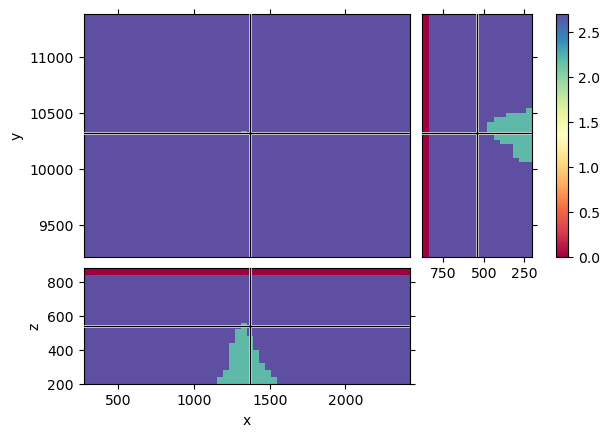

In [9]:
mesh.plot_3d_slicer(basic_cave_1_fwd_mesh, pcolor_opts={"cmap": "Spectral"})


In [10]:
# Create the muon simulation object. Assume 30 day exposure time
day = 86400.0 # number of seconds in a day
exposure_time = 90 * day # Exposure time in seconds
muon_counts_simulator = muon_simulation.MuonCountSimulation(
    mesh, sensors, exposure_time, n_rays_per_radiograph_pixel=10, model_map=active_map
)

In [11]:
is_active.sum(), print("Number of active cells in the muon forward simulation mesh:", is_active.sum())
d_muon_counts_target = muon_counts_simulator.get_data(basic_cave_1_fwd_mesh[is_active])

Number of active cells in the muon forward simulation mesh: 46656


### Parameterization

In [12]:
#################################################################################################################
# Parameterization
rbf_grid = ([mesh.cell_centers_x.min(), mesh.cell_centers_x.max()],
           [mesh.cell_centers_y.min(), mesh.cell_centers_y.max()],
           [mesh.cell_centers_z.min(), mesh.cell_centers_z.max()])

rbf_spacing = 40*6

z_rbf = np.arange(rbf_grid[2][0], rbf_grid[2][1] + rbf_spacing, rbf_spacing)
y_rbf = np.arange(rbf_grid[1][0], rbf_grid[1][1] + rbf_spacing, rbf_spacing)
x_rbf = np.arange(rbf_grid[0][0], rbf_grid[0][1] + rbf_spacing, rbf_spacing)

x_rbf_centre, y_rbf_centre, z_rbf_centre = np.meshgrid(x_rbf, y_rbf, z_rbf)
rbf_centres = np.c_[simpeg.utils.mkvc(x_rbf_centre), simpeg.utils.mkvc(y_rbf_centre), simpeg.utils.mkvc(z_rbf_centre)]


In [13]:

from scipy.spatial import KDTree

# Get all mesh cell centers
all_centers = mesh.cell_centers
tree = KDTree(all_centers)

rbf_spacing = 40*6

# Define the grid bounds (using the mesh cell center extremes)
rbf_grid = ([mesh.cell_centers_x.min(), mesh.cell_centers_x.max()],
           [mesh.cell_centers_y.min(), mesh.cell_centers_y.max()],
           [mesh.cell_centers_z.min(), mesh.cell_centers_z.max()])

# Create initial target points with desired spacing
z_rbf_target = np.arange(rbf_grid[2][0], rbf_grid[2][1] + rbf_spacing, rbf_spacing)
y_rbf_target = np.arange(rbf_grid[1][0], rbf_grid[1][1] + rbf_spacing, rbf_spacing)
x_rbf_target = np.arange(rbf_grid[0][0], rbf_grid[0][1] + rbf_spacing, rbf_spacing)

# Create a grid of target points
x_rbf_centre_target, y_rbf_centre_target, z_rbf_centre_target = np.meshgrid(x_rbf_target, y_rbf_target, z_rbf_target)
target_points = np.c_[simpeg.utils.mkvc(x_rbf_centre_target), 
                     simpeg.utils.mkvc(y_rbf_centre_target), 
                     simpeg.utils.mkvc(z_rbf_centre_target)]

# Find the nearest mesh cell centers for each target point
_, indices = tree.query(target_points)
rbf_centres = all_centers[indices]

#Define the core spacing
core_rbf_spacing = 40*2     # Denser spacing in the core
outer_rbf_spacing = rbf_spacing   # Sparser spacing outside the core

# Define the core area limits
core_x_lim = [x_min_sensors, x_max_sensors]  # Core area in x-direction
core_y_lim = [y_min_sensors, y_max_sensors]  # Core area in y-direction
core_z_lim = [z_min_sensors, 600]  # Core area in z-direction

# Create target points for the core grid with desired spacing
x_core_target = np.arange(core_x_lim[0], core_x_lim[1] + core_rbf_spacing, core_rbf_spacing)
y_core_target = np.arange(core_y_lim[0], core_y_lim[1] + core_rbf_spacing, core_rbf_spacing)
z_core_target = np.arange(core_z_lim[0], core_z_lim[1] + core_rbf_spacing, core_rbf_spacing)

# Create a grid of target points for core
x_core_centre_target, y_core_centre_target, z_core_centre_target = np.meshgrid(x_core_target, y_core_target, z_core_target)
core_target_points = np.c_[simpeg.utils.mkvc(x_core_centre_target), 
                         simpeg.utils.mkvc(y_core_centre_target), 
                         simpeg.utils.mkvc(z_core_centre_target)]

# Find the nearest mesh cell centers for each core target point
_, core_indices = tree.query(core_target_points)
core_centres = all_centers[core_indices]

# Create target points for the outer grid with desired spacing
x_outer_target = np.arange(rbf_grid[0][0], rbf_grid[0][1] + outer_rbf_spacing, outer_rbf_spacing)
y_outer_target = np.arange(rbf_grid[1][0], rbf_grid[1][1] + outer_rbf_spacing, outer_rbf_spacing)
z_outer_target = np.arange(rbf_grid[2][0], rbf_grid[2][1] + outer_rbf_spacing, outer_rbf_spacing)

# Create a grid of target points for outer region
x_outer_centre_target, y_outer_centre_target, z_outer_centre_target = np.meshgrid(x_outer_target, y_outer_target, z_outer_target)
outer_target_points = np.c_[simpeg.utils.mkvc(x_outer_centre_target), 
                          simpeg.utils.mkvc(y_outer_centre_target), 
                          simpeg.utils.mkvc(z_outer_centre_target)]

# Find the nearest mesh cell centers for each outer target point
_, outer_indices = tree.query(outer_target_points)
outer_centres_all = all_centers[outer_indices]

# Remove points in the outer grid that overlap with the core area
mask = ~(
    (outer_centres_all[:, 0] >= core_x_lim[0]) & (outer_centres_all[:, 0] <= core_x_lim[1]) &
    (outer_centres_all[:, 1] >= core_y_lim[0]) & (outer_centres_all[:, 1] <= core_y_lim[1]) &
    (outer_centres_all[:, 2] >= core_z_lim[0]) & (outer_centres_all[:, 2] <= core_z_lim[1])
)
outer_centres = outer_centres_all[mask]

# Combine core and outer centres
rbf_centres = np.vstack((core_centres, outer_centres))

# Set up RBF spacing array
n_rbf = rbf_centres.shape[0]
full_rbf_spacing = np.full(n_rbf, rbf_spacing)
core_mask = (
    (rbf_centres[:, 0] >= core_x_lim[0]) & (rbf_centres[:, 0] <= core_x_lim[1]) &
    (rbf_centres[:, 1] >= core_y_lim[0]) & (rbf_centres[:, 1] <= core_y_lim[1]) &
    (rbf_centres[:, 2] >= core_z_lim[0]) & (rbf_centres[:, 2] <= core_z_lim[1])
)
full_rbf_spacing[core_mask] = core_rbf_spacing
print('Num RBFs:' ,n_rbf)

Num RBFs: 878


In [16]:
import hashlib

def _sigma(alpha_raw):
    return np.arctan(alpha_raw * 0.5)

def _sigma_prime(alpha_raw):
    return 2.0 / (4.0 + alpha_raw * alpha_raw)

class MuonRBFKernel:
    def __init__(self, threshold=1e-8, digest_size=16):
        self.threshold = float(threshold)
        self.digest_size = int(digest_size)
        self.cache = {}

    def clear(self):
        self.cache.clear()

    def _arr_sig(self, a):
        a = np.ascontiguousarray(np.asarray(a))
        h = hashlib.blake2b(a.view(np.uint8), digest_size=self.digest_size).hexdigest()
        return (a.shape, str(a.dtype), h)

    def _geom_key(self, centres, xyz, rbf_w, eps, normalize_C):
        return (
            self._arr_sig(centres),
            self._arr_sig(xyz),
            self._arr_sig(rbf_w),
            float(eps),
            float(self.threshold),
            bool(normalize_C),
        )

    def _build_psi_grouped(self, centres, xyz, rbf_w):
        th = self.threshold
        tree_xyz = cKDTree(xyz)

        # Group centres by identical width to avoid global max-radius over-query.
        w_unique, w_inv = np.unique(rbf_w, return_inverse=True)

        row_all = []
        col_all = []
        dat_all = []

        for gi, w in enumerate(w_unique):
            idx = np.where(w_inv == gi)[0]
            if idx.size == 0:
                continue

            cen_g = centres[idx]
            tree_cen_g = cKDTree(cen_g)

            support_radius = float(w) * np.sqrt(-np.log(th))
            dist = tree_xyz.sparse_distance_matrix(
                tree_cen_g, max_distance=support_radius, output_type="coo_matrix"
            )

            if dist.nnz == 0:
                continue

            vals = np.exp(-(dist.data * dist.data) / (float(w) * float(w)))
            keep = vals > th
            if np.any(keep):
                row_all.append(dist.row[keep])
                col_all.append(idx[dist.col[keep]])  # map local group cols -> global cols
                dat_all.append(vals[keep])

        if len(dat_all) == 0:
            psi = sp.csr_matrix((xyz.shape[0], centres.shape[0]))
        else:
            rows = np.concatenate(row_all)
            cols = np.concatenate(col_all)
            data = np.concatenate(dat_all)
            psi = sp.csr_matrix((data, (rows, cols)), shape=(xyz.shape[0], centres.shape[0]))
            psi.sum_duplicates()
            psi.sort_indices()

        return psi

    def __call__(self, params, xyz, m, return_deriv=False, jvec=None, normalize_C=False):
        centres = np.asarray(params[0], dtype=np.float64)
        N = centres.shape[0]
        eps = float(params[1])
        rbf_w = np.asarray(params[2:2 + N], dtype=np.float64)
        xyz = np.asarray(xyz, dtype=np.float64)

        key = self._geom_key(centres, xyz, rbf_w, eps, normalize_C)

        if key not in self.cache:
            psi = self._build_psi_grouped(centres, xyz, rbf_w)

            row_sum = np.asarray(psi.sum(axis=1)).ravel()
            inv_row = 1.0 / (row_sum + 1e-12)
            row_idx = np.repeat(np.arange(psi.shape[0]), np.diff(psi.indptr))

            self.cache[key] = {
                "psi": psi,
                "inv_row": inv_row,
                "row_idx": row_idx,
                "pi_over_eps": np.pi / eps,
                "inv_pi": 1.0 / np.pi,
            }

        c = self.cache[key]
        psi = c["psi"]
        inv_row = c["inv_row"]
        row_idx = c["row_idx"]

        alpha_raw = np.asarray(m[:N], dtype=np.float64)
        c_low = float(m[N])
        c_high = float(m[N + 1])

        # Muon case: low-contrast anomaly in high background.
        # T ~ 1 in anomaly region => f ~ c_low, T ~ 0 in background => f ~ c_high.
        contrast = c_low - c_high

        sigma_a = _sigma(alpha_raw)
        phi = psi @ sigma_a
        if normalize_C:
            phi = inv_row * phi

        arg = c["pi_over_eps"] * phi
        T = 0.5 + c["inv_pi"] * np.arctan(arg)

        if (not return_deriv) and (jvec is None):
            return c_high + contrast * T

        T_p = 1.0 / (eps * (1.0 + arg * arg))
        sigma_p = _sigma_prime(alpha_raw)

        row_scale = contrast * T_p
        if normalize_C:
            row_scale = inv_row * row_scale

        J_alpha = psi.copy()
        J_alpha.data *= sigma_p[J_alpha.indices]
        J_alpha.data *= row_scale[row_idx]

        J_clow = sp.csr_matrix(T.reshape(-1, 1))
        J_chigh = sp.csr_matrix((1.0 - T).reshape(-1, 1))

        return sp.hstack([J_alpha, J_clow, J_chigh], format="csr")

# Instantiate once and pass into ParametricRBFMapping
rbf_kernel = MuonRBFKernel(threshold=1e-8)

In [17]:
## Initialize the model by activating the RBFs within X metres of the centre
indices = np.arange(n_rbf)
centre = np.array([1400, 10300, 200])
index_centre = np.where((rbf_centres == centre).all(axis=1))[0]
distances = np.sqrt(np.sum((rbf_centres - centre)**2, axis=1))
cave_ind = np.where(distances <= 180)[0]

In [18]:

### Initial model parameters
alpha_init =  -1.0 * np.ones(n_rbf)
alpha_init[cave_ind] = 3.0
c_low_init = 2.2
c_high_init = 3.0

param_model = np.r_[alpha_init, c_low_init, c_high_init]

# Set the background and air density and cave density
air_density = 0.0
background_density = 2.7
cave_density = 2.2
eps_init = 1.0

# Define extra fixed parameters (not being inverted for)
extra_params = [rbf_centres, eps_init, *full_rbf_spacing,] #*c_low_init, *c_high_init]

num_params = len(param_model)

###### MAPPING ######
torch_map = simpeg.maps.ParametricRBFMapping(mesh=mesh,nP=num_params,active_cells=is_active,
                                       params=extra_params,forward_transform=rbf_kernel)
                                       
model_map = simpeg.maps.IdentityMap(mesh)
param_map = active_map*torch_map
###
model_init = param_map * param_model

Plot models

Initial parametric model
Ground truth model


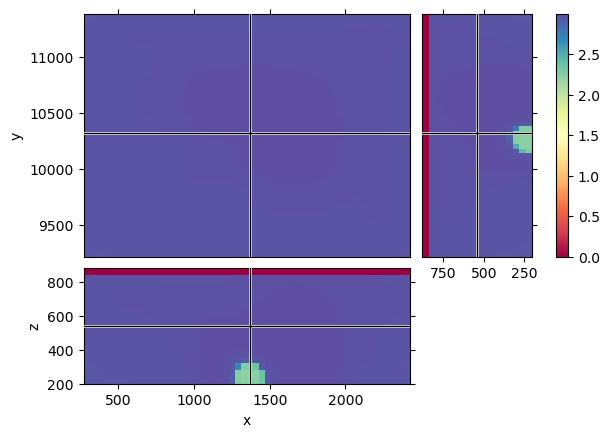

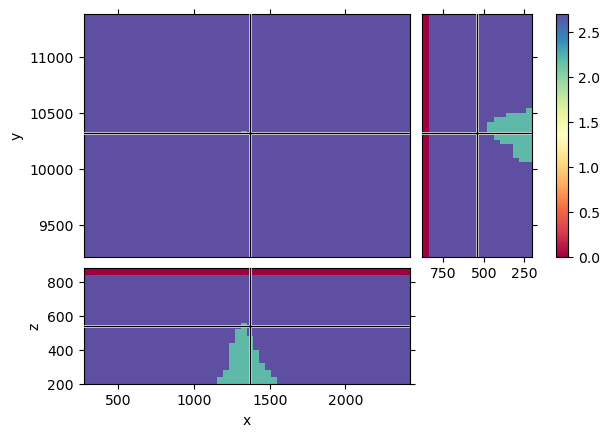

In [19]:
print("Initial parametric model")
mesh.plot_3d_slicer(model_init, pcolor_opts={"cmap": "Spectral"})
print("Ground truth model")
mesh.plot_3d_slicer(basic_cave_1_fwd_mesh, pcolor_opts={"cmap": "Spectral"})


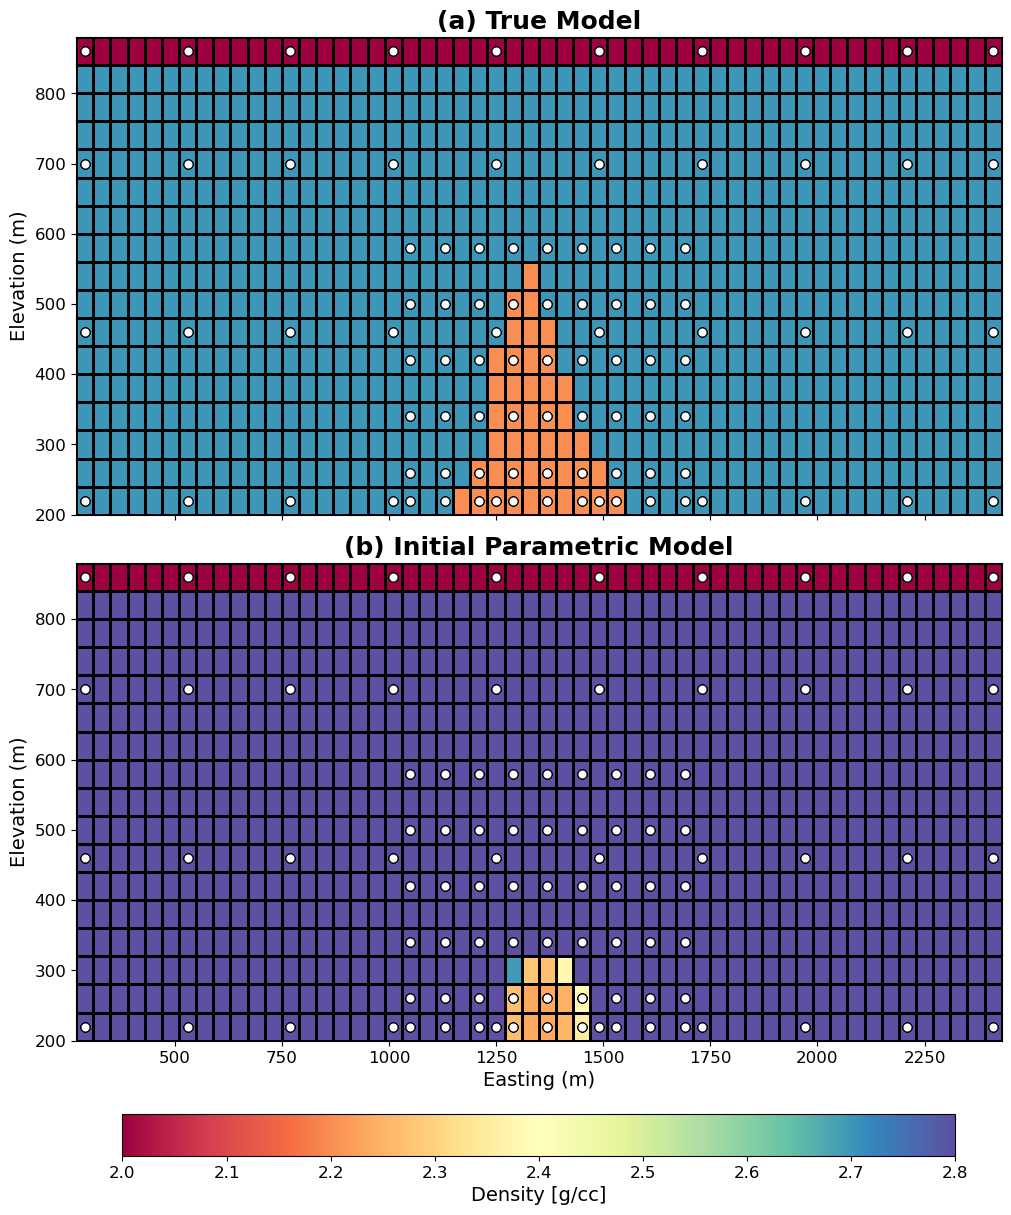

In [59]:
# Plot slice through the model with RBF centres
def plot_init_true(param_model, plot_model=False):
    if plot_model:
        fig, axes = plt.subplots(2, 1, figsize=(10, 12), constrained_layout=True)
    else:
        fig, axes = plt.subplots(1, 1, figsize=(10, 6), constrained_layout=True)
        axes = [axes]

    y_ind = int(mesh.h[1].size / 2)
    clim = (2.0, 2.8)

    if plot_model:
        # True model first (top row)
        ax_true = axes[0]
        mappable_true = mesh.plot_slice(
            basic_cave_1_fwd_mesh, normal="Y", ax=ax_true, ind=y_ind, grid=True,
            clim=clim, pcolor_opts={"cmap": "Spectral"}
        )
        ax_true.scatter(
            rbf_centres[:, 0], rbf_centres[:, 2],
            c="white", s=42, alpha=0.95, edgecolors="black", linewidths=0.7, zorder=8
        )
        ax_true.set_title("(a) True Model", fontsize=18, fontweight="bold")
        ax_true.set_xlabel("")
        ax_true.set_ylabel("Elevation (m)", fontsize=14)
        ax_true.tick_params(labelsize=12)
        ax_true.tick_params(axis="x", labelbottom=False, bottom=True)

        # Initial parametric model second (bottom row)
        ax_init = axes[1]
    else:
        ax_init = axes[0]

    mappable_init = mesh.plot_slice(
        param_map * param_model, normal="Y", ax=ax_init, ind=y_ind, grid=True,
        clim=clim, pcolor_opts={"cmap": "Spectral"}
    )
    ax_init.scatter(
        rbf_centres[:, 0], rbf_centres[:, 2],
        c="white", s=42, alpha=0.95, edgecolors="black", linewidths=0.7, zorder=8
    )
    title_txt = "(b) Initial Parametric Model" if plot_model else "Initial Parametric Model"
    ax_init.set_title(title_txt, fontsize=18, fontweight="bold")
    ax_init.set_xlabel("Easting (m)", fontsize=14)
    ax_init.set_ylabel("Elevation (m)", fontsize=14)
    ax_init.tick_params(labelsize=12)

    # Shared colorbar at the bottom
    cbar = fig.colorbar(
        mappable_init[0], ax=axes, orientation="horizontal", shrink=0.9, pad=0.02
    )
    cbar.set_label("Density [g/cc]", size=14)
    cbar.ax.tick_params(labelsize=12)

    plt.show()

plot_init_true(param_model, plot_model=True)

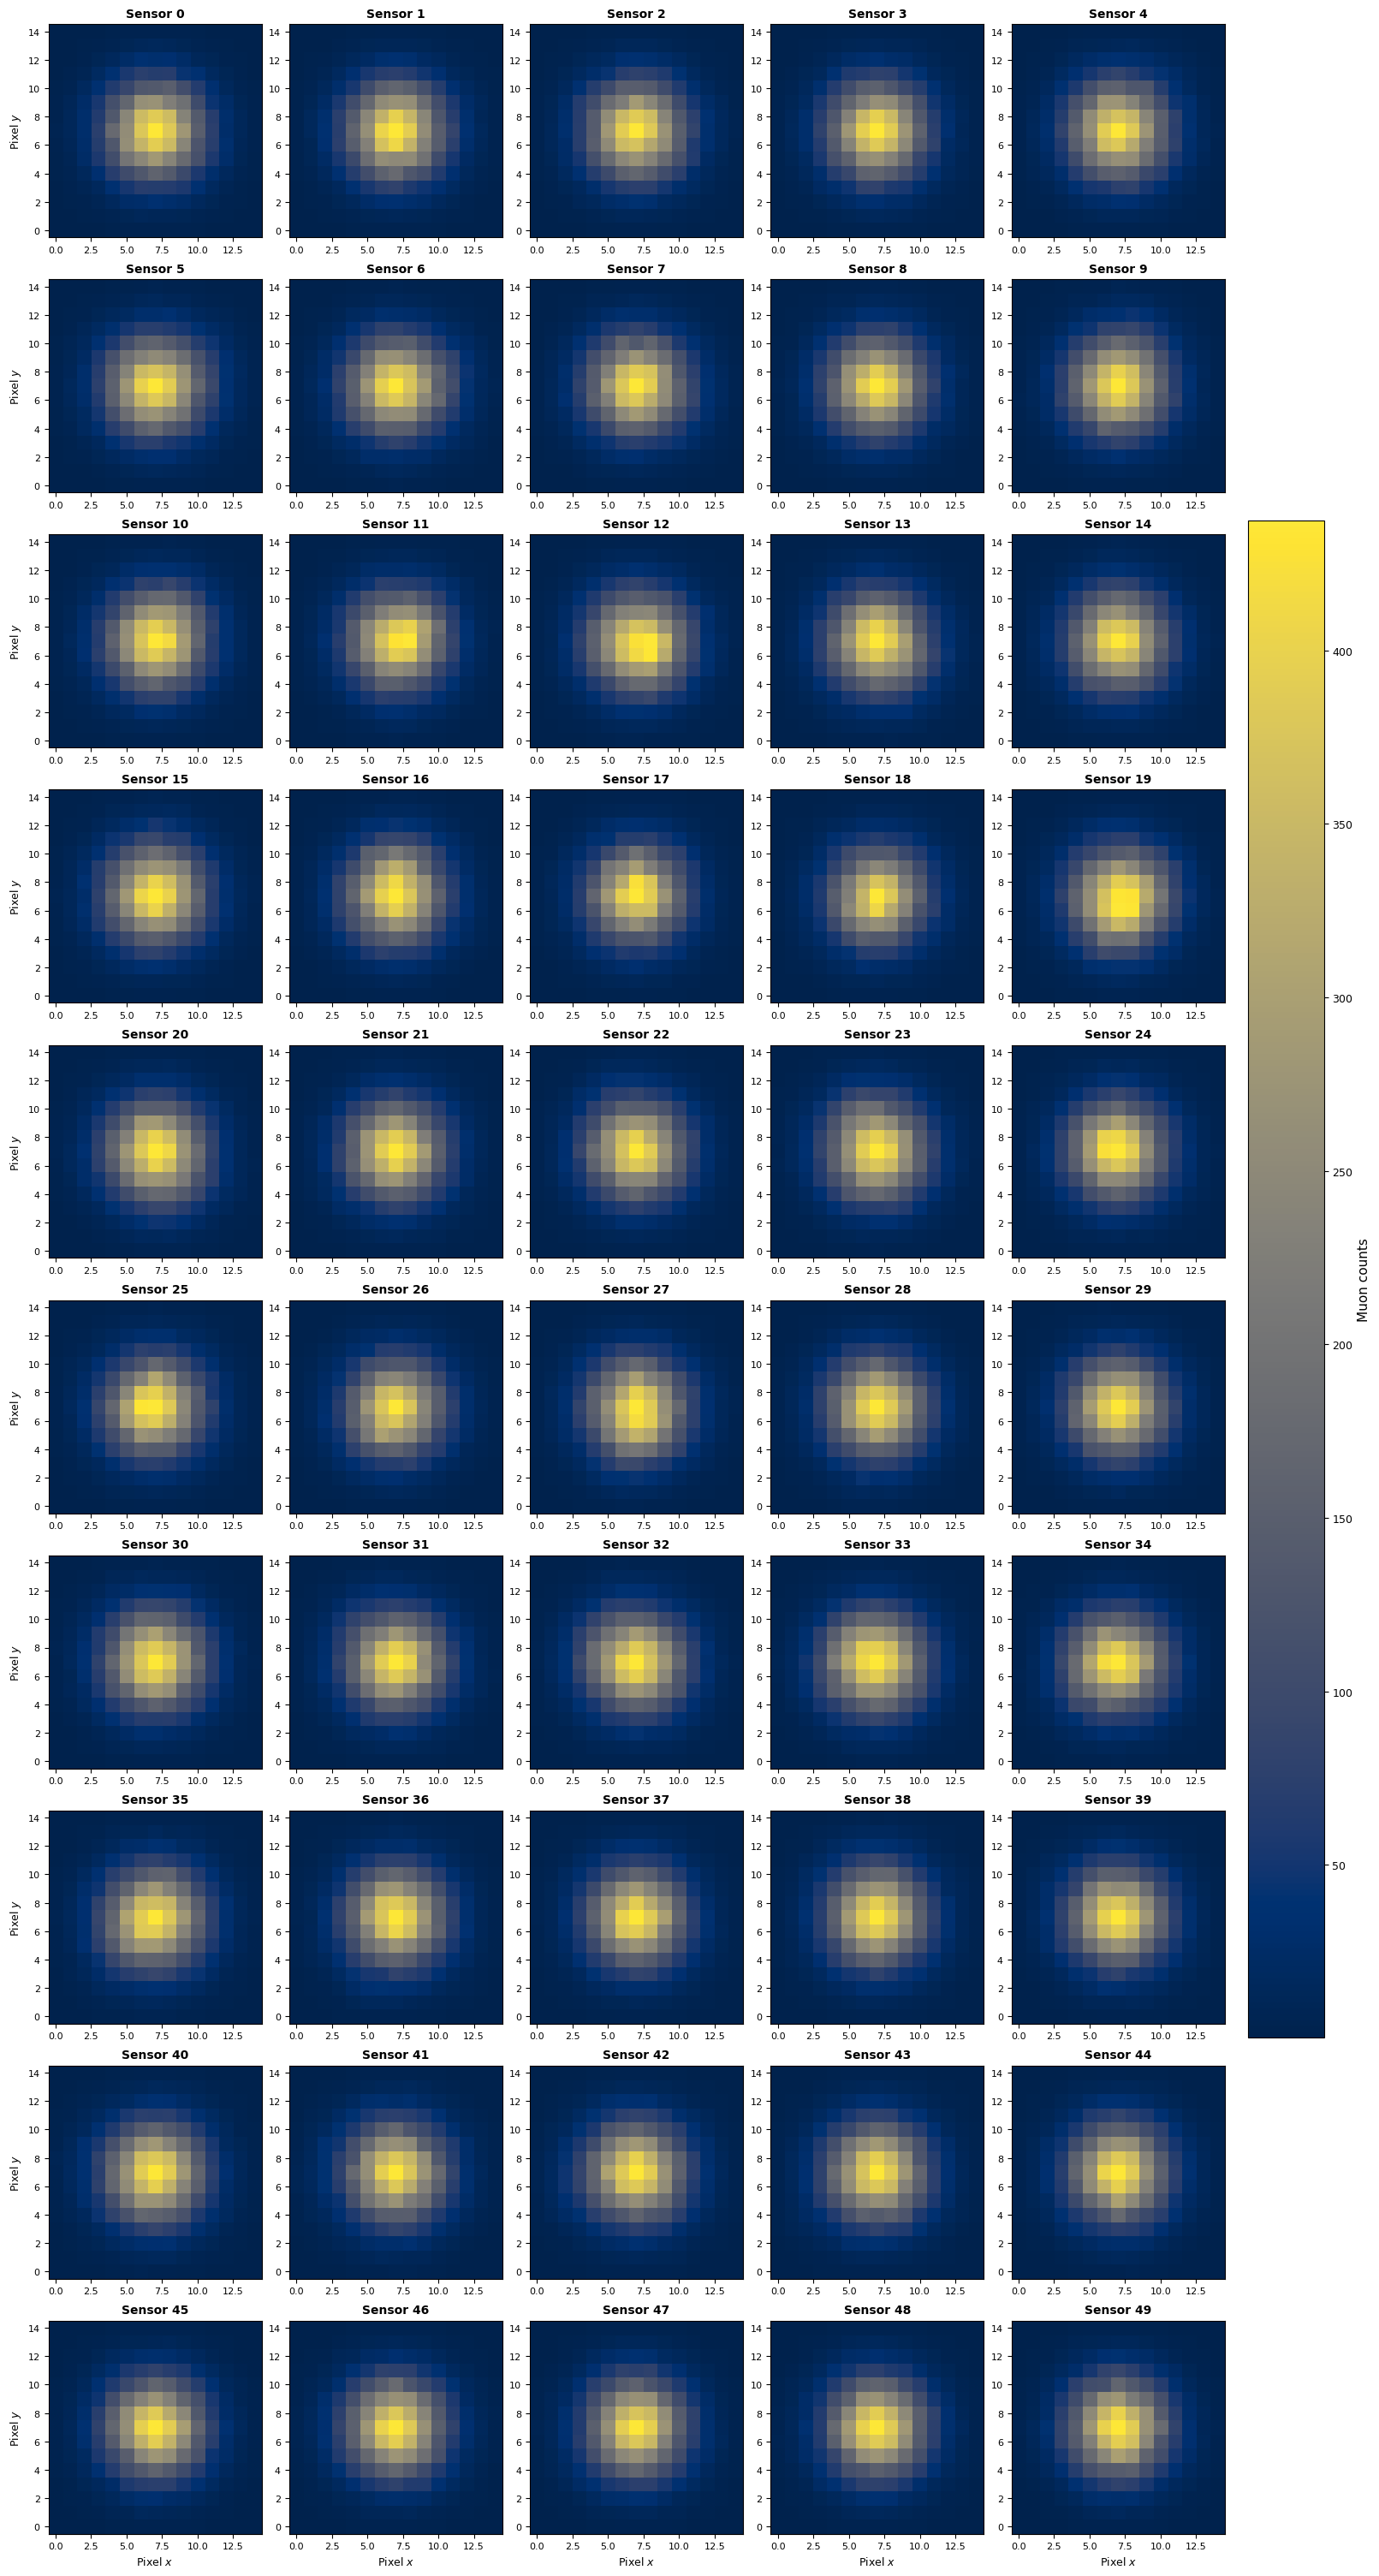

In [ ]:
## Sanity check the forward simulation based on non-parametric reference model 
reference_density_model = np.full(mesh.n_cells, air_density)
reference_density_model[is_active] = background_density
d_muon_counts_reference = muon_counts_simulator.get_data(reference_density_model[is_active])

#  radiograph figure
n_pixels = n_bins_x * n_bins_y
n_sensors = len(sensors)
n_cols = min(5, n_sensors)
n_rows = int(np.ceil(n_sensors / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(3.2*n_cols, 3*n_rows), constrained_layout=True)
axs_flat = axs.flatten() if n_sensors > 1 else [axs]

offset = 0
for i in range(n_sensors):
    ax = axs_flat[i]
    counts = d_muon_counts_target[offset:offset+n_pixels].reshape(n_bins_y, n_bins_x).T
    im = ax.imshow(counts, origin='lower', cmap='cividis', aspect='equal')
    ax.set_title(f"Sensor {i}", fontsize=13, fontweight="bold")
    if i % n_cols == 0:
        ax.set_ylabel("Pixel $y$", fontsize=11)
    if i >= n_sensors - n_cols:
        ax.set_xlabel("Pixel $x$", fontsize=11)
    ax.tick_params(labelsize=10)
    offset += n_pixels

# Hide unused subplots
for j in range(n_sensors, len(axs_flat)):
    axs_flat[j].set_visible(False)

# Shared colorbar
cbar = fig.colorbar(im, ax=axs_flat[:n_sensors], orientation="vertical", 
                    shrink=0.6, pad=0.02)
cbar.set_label("Muon counts", fontsize=12)
cbar.ax.tick_params(labelsize=10)

plt.show()

### RBF inversion
Update alphas and contrasts simultaneously

In [22]:
dobs = d_muon_counts_target + np.random.poisson(0.01*d_muon_counts_target)
std = np.sqrt(dobs)

sim = muon_simulation.MuonCountSimulation(
    mesh, sensors, exposure_time,
    n_rays_per_radiograph_pixel=10,
    model_map = param_map)

print(len(param_model))
print("Number of RBFs:", n_rbf)

880
Number of RBFs: 878


In [38]:
# Define regularization 
reg_alpha_vals = -0.1 * np.ones(n_rbf)
reg_clow_vals = 2.2 * np.ones(n_rbf) 
reg_chigh_vals = 3.0* np.ones(n_rbf)
reg_param_model =np.r_ [reg_alpha_vals, reg_clow_vals, reg_chigh_vals]

# optimization bounds
low_bound = np.r_[-10 * np.ones(n_rbf), 2.0, 2.4]
high_bound = np.r_[10 * np.ones(n_rbf), 2.3, 3.0]

In [ ]:
data = simpeg.Data(survey=sim.survey, dobs=dobs, standard_deviation=std)
data_misfit = simpeg.data_misfit.L2DataMisfit(simulation=sim, data=data)

# Optimization
opt = simpeg.optimization.ProjectedGNCG(maxIter=40, maxIterLS=50, maxIterCG=20, 
                                        lower=low_bound, upper=high_bound)

reg = simpeg.regularization.WeightedLeastSquares(TensorMesh([np.ones(num_params)]),)
    # alpha_s=1e-6,
    # alpha_x=1.0,
    # alpha_y=1.0,
    # alpha_z=1.0,
    # reference_model_in_smooth=True)

inv_prob = simpeg.inverse_problem.BaseInvProblem(data_misfit, reg, opt, beta=1e2)

# Directives
save_output_rbf = simpeg.directives.SaveOutputEveryIteration(save_txt=False)
target = simpeg.directives.TargetMisfit(chifact=0.5)

directives = [
    save_output_rbf,
    simpeg.directives.BetaSchedule(coolingFactor=2, coolingRate=2),
    target,
]

inv = simpeg.inversion.BaseInversion(inv_prob, directiveList=directives)
mrec = inv.run(param_model)

C:\Users\parth\AppData\Local\Temp\ipykernel_54544\1137754742.py:5: FutureWarning: The defaults for ProjectedGNCG will change in SimPEG 0.26.0. If you want to maintain the previous behavior, explicitly set 'cg_atol=1E-3' and 'cg_rtol=0.0'.
  opt = simpeg.optimization.ProjectedGNCG(maxIter=30, maxIterLS=50, maxIterCG=20,
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: simpeg.InvProblem will set Regularization.reference_model to m0.
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 5625.0



Running inversion with SimPEG v0.25.0
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.00e+03  1.17e+05  3.63e+02  4.80e+05                         0           inf          inf                
   1  1.00e+03  2.09e+04  1.52e+02  1.73e+05    2.01e+02      0      7        8.26e-09     4.92e-04              
   2  1.00e+03  1.00e+04  1.52e+02  1.62e+05    1.60e+02      0      20       3.77e-04     1.16e+02              
   3  5.00e+02  9.92e+03  1.52e+02  8.60e+04    9.30e+01      0      9        2.86e-08     4.70e-04   Skip BFGS  
   4  5.00e+02  9.91e+03  1.52e+02  8.59e+04    1.29e+02      2      20       2.27e+00     6.48e+04              
   5  2.50e+02  9.78e+03  1.52e+02  4.78e+04    

### L2 Inversion

In [45]:
# L2 inversion on the active-cell density model
n_active = int(is_active.sum())
l2_map = simpeg.maps.InjectActiveCells(mesh, is_active, value_inactive=0.0)

sim_l2 = muon_simulation.MuonCountSimulation(
    mesh, sensors, exposure_time,
    n_rays_per_radiograph_pixel=10,
    model_map=active_map,
)

In [48]:
# # Now run an inversion to recover the density model from the muon count data
simpeg_data_container = simpeg.Data(
    survey = muon_counts_simulator.survey,
    dobs = d_muon_counts_target + np.random.poisson(0.01*d_muon_counts_target),
    standard_deviation = np.sqrt(dobs),
)

dmis = simpeg.data_misfit.L2DataMisfit(
    simulation=muon_counts_simulator,
    data=simpeg_data_container,
)

In [49]:
m0_l2 = np.full(is_active.sum(), 2.2)

data_l2 = simpeg.Data(survey=sim_l2.survey, dobs=dobs, standard_deviation=std)
data_misfit_l2 = dmis

reg_l2 = simpeg.regularization.WeightedLeastSquares(
    mesh=mesh,
    active_cells=is_active,#active_map.active_cells,
    reference_model = m0_l2,
    alpha_s=1e-6,
    alpha_x=1.0,
    alpha_y=1.0,
    alpha_z=1.0,
    #reference_model_in_smooth=True,
)

low_bound_l2 = 2.0
high_bound_l2 = 3.0


opt_l2 = simpeg.optimization.ProjectedGNCG(
    maxIter=25, maxIterLS=12, maxIterCG=10,    lower=low_bound_l2, upper=high_bound_l2,
 )

inv_prob_l2 = simpeg.inverse_problem.BaseInvProblem(data_misfit_l2, reg_l2, opt_l2, beta=0.1)
save_output_l2 = simpeg.directives.SaveOutputEveryIteration(save_txt=False)
directives_l2 = [
    #simpeg.directives.BetaEstimate_ByEig(beta0_ratio=1e-2),
    save_output_l2,
    simpeg.directives.BetaSchedule(coolingFactor=1.5, coolingRate=2),
    simpeg.directives.TargetMisfit(chifact=0.5),
]

inv_l2 = simpeg.inversion.BaseInversion(inv_prob_l2, directiveList=directives_l2)
mrec_l2_active = inv_l2.run(m0_l2)

# Expand active-cell L2 model back to full mesh for plotting
mrec_l2 = np.full(mesh.n_cells, air_density)
mrec_l2[is_active] = mrec_l2_active

C:\Users\parth\AppData\Local\Temp\ipykernel_54544\3473840258.py:21: FutureWarning: The defaults for ProjectedGNCG will change in SimPEG 0.26.0. If you want to maintain the previous behavior, explicitly set 'cg_atol=1E-3' and 'cg_rtol=0.0'.
  opt_l2 = simpeg.optimization.ProjectedGNCG(
INFO: 
simpeg.InvProblem is setting bfgsH0 to the inverse of the reg.deriv2.
using the default solver Pardiso with the 'is_symmetric=True` option set.

INFO: Directive TargetMisfit: Target data misfit is 5625.0



Running inversion with SimPEG v0.25.0
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  1.00e-01  8.57e+05  0.00e+00  8.57e+05                         0           inf          inf                
   1  1.00e-01  5.12e+04  4.58e+02  5.13e+04    7.51e+01      0      10       7.74e-03     5.98e+02              
   2  1.00e-01  9.44e+02  1.21e+03  1.06e+03    5.19e+01      0      10       1.91e-02     1.98e+02   Skip BFGS  
------------------------- STOP! -------------------------
1 : |fc-fOld| = 5.0223e+04 <= tolF*(1+|f0|) = 8.5743e+04
1 : |xc-x_last| = 3.1360e+01 <= tolX*(1+|x0|) = 4.7620e+01
0 : |proj(x-g)-x|    = 5.1886e+01 <= tolG          = 1.0000e-01
0 : |proj(x-g)-x|    = 5.1886e+01 <= 1

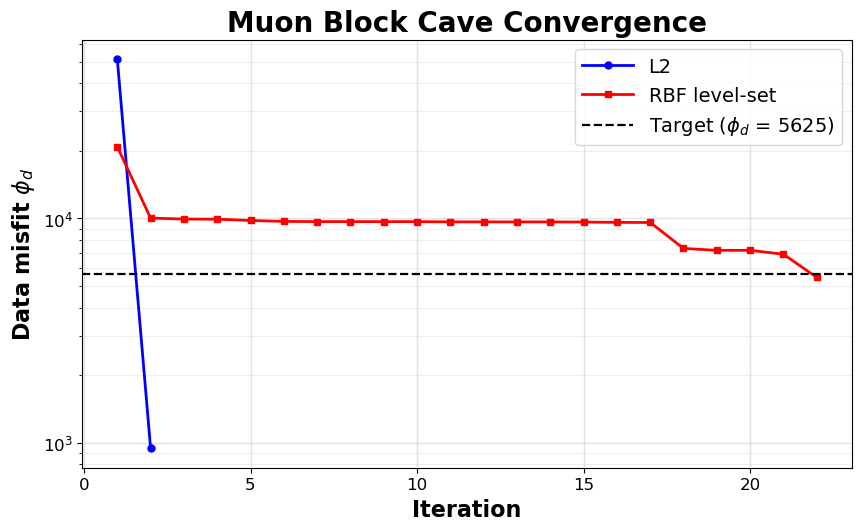

In [77]:
# ============================================================
# Convergence curves (RBF vs L2)
# ============================================================

def _history_from_save(save_output):
    out = getattr(save_output, "outDict", None)
    if out:
        try:
            sample = next(iter(out.values()))
        except StopIteration:
            sample = None
        if isinstance(sample, dict) and "phi_d" in sample:
            iters = np.array(sorted(out.keys()))
            phi_d = np.array([out[i]["phi_d"] for i in iters])
            phi = np.array([out[i].get("phi", out[i]["phi_d"]) for i in iters])
            return iters, phi_d, phi
        if "phi_d" in out:
            phi_d = np.asarray(out["phi_d"])
            iters = np.arange(1, phi_d.size + 1)
            phi = np.asarray(out.get("phi", phi_d))
            return iters, phi_d, phi
    phi_d = np.asarray(getattr(save_output, "phi_d", []))
    if phi_d.size:
        iters = np.arange(1, phi_d.size + 1)
        phi = np.asarray(getattr(save_output, "phi", phi_d))
        return iters, phi_d, phi
    return None, None, None

iters_rbf, phi_d_rbf, phi_rbf = (None, None, None)
iters_l2, phi_d_l2, phi_l2 = (None, None, None)
if "save_output_rbf" in globals():
    iters_rbf, phi_d_rbf, phi_rbf = _history_from_save(save_output_rbf)
if "save_output_l2" in globals():
    iters_l2, phi_d_l2, phi_l2 = _history_from_save(save_output_l2)

fig, ax = plt.subplots(1, 1, figsize=(8.5, 5.2), constrained_layout=True)

has_any = False
if phi_d_l2 is not None:
    ax.semilogy(
        iters_l2,
        phi_d_l2,
        color="blue",
        marker="o",
        ms=5,
        lw=2.0,
        label="L2",
    )
    has_any = True
if phi_d_rbf is not None:
    ax.semilogy(
        iters_rbf,
        phi_d_rbf,
        color="red",
        marker="s",
        ms=5,
        lw=2.0,
        label="RBF level-set",
    )
    has_any = True

ax.set_title("Muon Block Cave Convergence", fontsize=20, fontweight="bold")
ax.set_xlabel("Iteration", fontsize=16, fontweight="bold")
ax.set_ylabel(r"Data misfit $\phi_d$", fontsize=16, fontweight="bold")

if has_any:
    target_misfit = float(target.chifact) * float(data.nD)
    ax.axhline(
        target_misfit,
        ls="--",
        color="black",
        lw=1.6,
        label=f"Target ($\\phi_d$ = {target_misfit:.0f})",
    )
    ax.legend(loc="upper right", frameon=True, fontsize=14, handlelength=2.6)
    ax.grid(True, which="major", alpha=0.35, linewidth=1.0)
    ax.grid(True, which="minor", alpha=0.2, linewidth=0.8)
    ax.tick_params(axis="both", which="both", labelsize=12)
else:
    ax.text(0.5, 0.5, "Re-run inversions to capture history", ha="center", va="center")
    ax.set_axis_off()

plt.show()

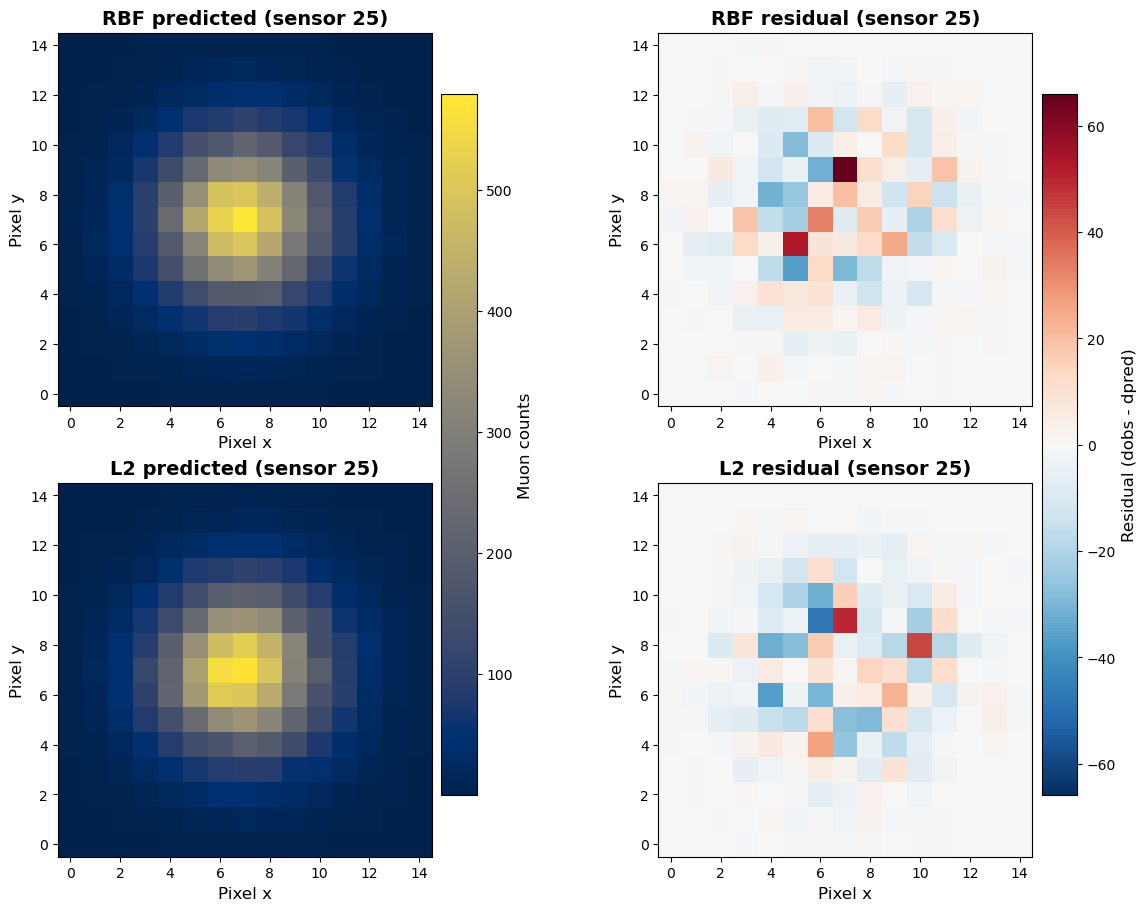

In [78]:
# ============================================================
# Predicted data / residual panels (RBF vs L2)
# ============================================================

# Predicted data + residuals (use a representative sensor)
dpred_rbf = sim.dpred(mrec)
dpred_l2 = sim_l2.dpred(mrec_l2_active)
resid_rbf = dobs - dpred_rbf
resid_l2 = dobs - dpred_l2

sensor_idx = min(n_sensors // 2, n_sensors - 1)

def _sensor_image(vec, sensor_i):
    offset = sensor_i * n_pixels
    return vec[offset:offset + n_pixels].reshape(n_bins_y, n_bins_x).T

pred_rbf_img = _sensor_image(dpred_rbf, sensor_idx)
pred_l2_img = _sensor_image(dpred_l2, sensor_idx)
resid_rbf_img = _sensor_image(resid_rbf, sensor_idx)
resid_l2_img = _sensor_image(resid_l2, sensor_idx)

pred_vmin = min(pred_rbf_img.min(), pred_l2_img.min())
pred_vmax = max(pred_rbf_img.max(), pred_l2_img.max())
resid_lim = max(np.abs(resid_rbf_img).max(), np.abs(resid_l2_img).max())

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

# Row 1: RBF predicted + residual
ax = axes[0, 0]
im_pred_rbf = ax.imshow(pred_rbf_img, origin="lower", cmap="cividis",
                        vmin=pred_vmin, vmax=pred_vmax, aspect="equal")
ax.set_title(f"RBF predicted (sensor {sensor_idx})", fontsize=14, fontweight="bold")
ax.set_xlabel("Pixel x", fontsize=12)
ax.set_ylabel("Pixel y", fontsize=12)
ax.tick_params(labelsize=10)

ax = axes[0, 1]
im_resid_rbf = ax.imshow(resid_rbf_img, origin="lower", cmap="RdBu_r",
                         vmin=-resid_lim, vmax=resid_lim, aspect="equal")
ax.set_title(f"RBF residual (sensor {sensor_idx})", fontsize=14, fontweight="bold")
ax.set_xlabel("Pixel x", fontsize=12)
ax.set_ylabel("Pixel y", fontsize=12)
ax.tick_params(labelsize=10)

# Row 2: L2 predicted + residual
ax = axes[1, 0]
im_pred_l2 = ax.imshow(pred_l2_img, origin="lower", cmap="cividis",
                       vmin=pred_vmin, vmax=pred_vmax, aspect="equal")
ax.set_title(f"L2 predicted (sensor {sensor_idx})", fontsize=14, fontweight="bold")
ax.set_xlabel("Pixel x", fontsize=12)
ax.set_ylabel("Pixel y", fontsize=12)
ax.tick_params(labelsize=10)

ax = axes[1, 1]
im_resid_l2 = ax.imshow(resid_l2_img, origin="lower", cmap="RdBu_r",
                        vmin=-resid_lim, vmax=resid_lim, aspect="equal")
ax.set_title(f"L2 residual (sensor {sensor_idx})", fontsize=14, fontweight="bold")
ax.set_xlabel("Pixel x", fontsize=12)
ax.set_ylabel("Pixel y", fontsize=12)
ax.tick_params(labelsize=10)

# Shared colorbars for predicted and residual panels
cbar_pred = fig.colorbar(im_pred_rbf, ax=axes[:, 0], orientation="vertical", shrink=0.85, pad=0.02)
cbar_pred.set_label("Muon counts", fontsize=12)
cbar_pred.ax.tick_params(labelsize=10)

cbar_resid = fig.colorbar(im_resid_rbf, ax=axes[:, 1], orientation="vertical", shrink=0.85, pad=0.02)
cbar_resid.set_label("Residual (dobs - dpred)", fontsize=12)
cbar_resid.ax.tick_params(labelsize=10)

plt.show()

Recovered c_low (anomaly): 2.180 g/cc
Recovered c_high (background): 2.706 g/cc
Alpha range: [-2.10, 3.38]


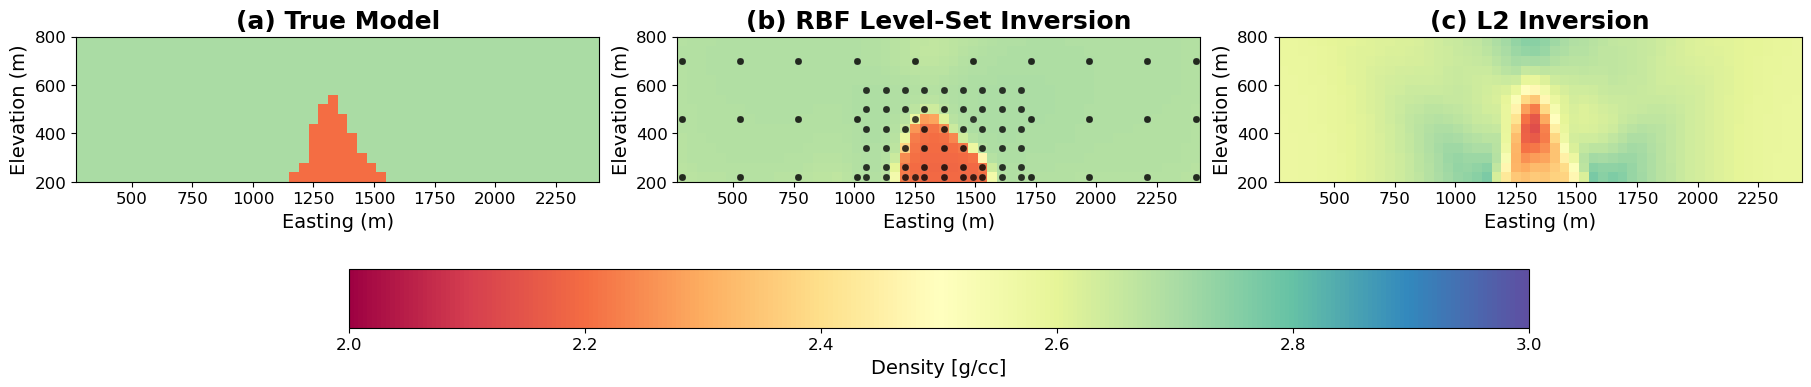

In [74]:
# ============================================================
# Publication figure: True vs Recovered (RBF and L2)
# ============================================================
recovered_model = param_map * mrec
recovered_model_l2 = mrec_l2
true_model = basic_cave_1_fwd_mesh

# Extract the recovered contrast values for RBF inversion
alpha_rec = mrec[:n_rbf]
c_low_rec = mrec[n_rbf]
c_high_rec = mrec[n_rbf + 1]
print(f"Recovered c_low (anomaly): {c_low_rec:.3f} g/cc")
print(f"Recovered c_high (background): {c_high_rec:.3f} g/cc")
print(f"Alpha range: [{alpha_rec.min():.2f}, {alpha_rec.max():.2f}]")

# Y-slice (cross-section through cave centre)
y_ind = int(mesh.h[1].size / 2)
clim = (2.0, 3.0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)

# (a) True Model
ax = axes[0]
mappable_true = mesh.plot_slice(true_model, normal="Y", ax=ax, ind=y_ind, grid=False,
                                clim=clim, pcolor_opts={"cmap": "Spectral"})
ax.set_title("(a) True Model", fontsize=18, fontweight="bold")
ax.set_xlabel("Easting (m)", fontsize=14)
ax.set_ylabel("Elevation (m)", fontsize=14)
ax.set_ylim(200, 800)
ax.set_aspect("equal")
ax.tick_params(labelsize=12)

# (b) RBF inversion
ax = axes[1]
mesh.plot_slice(recovered_model, normal="Y", ax=ax, ind=y_ind, grid=False,
                clim=clim, pcolor_opts={"cmap": "Spectral"})
ax.scatter(rbf_centres[:, 0], rbf_centres[:, 2], c="k", s=25, alpha=0.15,
           edgecolors="w", linewidths=0.1, zorder=8)
ax.set_title("(b) RBF Level-Set Inversion", fontsize=18, fontweight="bold")
ax.set_xlabel("Easting (m)", fontsize=14)
ax.set_ylabel("Elevation (m)", fontsize=14)
ax.set_ylim(200, 800)
ax.set_aspect("equal")
ax.tick_params(labelsize=12)

# (c) L2 inversion
ax = axes[2]
mesh.plot_slice(recovered_model_l2, normal="Y", ax=ax, ind=y_ind, grid=False,
                clim=clim, pcolor_opts={"cmap": "Spectral"})
ax.set_title("(c) L2 Inversion", fontsize=18, fontweight="bold")
ax.set_xlabel("Easting (m)", fontsize=14)
ax.set_ylabel("Elevation (m)", fontsize=14)
ax.set_ylim(200, 800)
ax.set_aspect("equal")
ax.tick_params(labelsize=12)

# Shared colorbar
cbar = fig.colorbar(mappable_true[0], ax=axes, orientation="horizontal", shrink=0.85, pad=0.08)
cbar.set_label("Density [g/cc]", size=14)
cbar.ax.tick_params(labelsize=12)

plt.show()

### Multi-slice comparison

In [75]:
# ============================================================
# Multi-slice figures: split into Y-slices and X-slices
# ============================================================
y_inds = [int(mesh.h[1].size * f) for f in [0.47, 0.5, 0.53]]
x_inds = [int(mesh.h[0].size * f) for f in [0.47, 0.5, 0.53]]
n_slices = len(y_inds)

models = [
    ("True", true_model, False),
    ("RBF", recovered_model, True),
    ("L2", recovered_model_l2, False),
]
clim = (2.0, 3.0)

cave_xlim_xz = None
cave_xlim_yz = None
cave_zlim = None
if "cave_ind" in globals() and cave_ind.size > 0:
    cave_pts = rbf_centres[cave_ind]
    pad_xy = 300.0
    pad_z = 300.0
    cave_xlim_xz = (cave_pts[:, 0].min() - pad_xy, cave_pts[:, 0].max() + pad_xy)
    cave_xlim_yz = (cave_pts[:, 1].min() - pad_xy, cave_pts[:, 1].max() + pad_xy)
    z_min = max(200.0, cave_pts[:, 2].min() - pad_z)
    cave_zlim = (z_min, cave_pts[:, 2].max() + pad_z)

# ============================================================
# Figure 1: Y-slices (X-Z view)
# ============================================================
fig_y, axes_y = plt.subplots(
    3, n_slices, figsize=(4.2*n_slices, 10.8), constrained_layout=True, dpi=600
)
mappable_ref_y = None

for r, (name, model, show_rbf_pts) in enumerate(models):
    for j, yi in enumerate(y_inds):
        y_val = mesh.cell_centers_y[yi]
        ax = axes_y[r, j]
        mappable = mesh.plot_slice(
            model, normal="Y", ax=ax, ind=yi, grid=False,
            clim=clim, pcolor_opts={"cmap": "Spectral"}
        )
        if mappable_ref_y is None:
            mappable_ref_y = mappable[0]

        if show_rbf_pts:
            ax.scatter(
                rbf_centres[:, 0], rbf_centres[:, 2],
                c="k", s=10, alpha=0.2, edgecolors="k", linewidths=0.1, zorder=8
            )

        if cave_xlim_xz is not None:
            ax.set_xlim(cave_xlim_xz)
        if cave_zlim is not None:
            ax.set_ylim(cave_zlim)

        ax.set_title(f"{name} model | y = {y_val:.0f} m", fontsize=16, fontweight="bold")
        if j == 0:
            ax.set_ylabel("Elevation (m)", fontsize=14)
        else:
            ax.set_ylabel("")

        if r < 2:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False, bottom=True)
        else:
            ax.set_xlabel("Easting (m)", fontsize=14)
        ax.tick_params(labelsize=12)

cbar_y = fig_y.colorbar(
    mappable_ref_y, ax=axes_y, orientation="horizontal", shrink=0.82, pad=0.03
)
cbar_y.set_label("Density [g/cc]", size=14, fontweight="bold")
cbar_y.ax.tick_params(labelsize=12)
plt.show()

# ============================================================
# Figure 2: X-slices (Y-Z view)
# ============================================================
fig_x, axes_x = plt.subplots(
    3, n_slices, figsize=(4.2*n_slices, 10.8), constrained_layout=True, dpi=600
)
mappable_ref_x = None

for r, (name, model, show_rbf_pts) in enumerate(models):
    for j, xi in enumerate(x_inds):
        x_val = mesh.cell_centers_x[xi]
        ax = axes_x[r, j]
        mappable = mesh.plot_slice(
            model, normal="X", ax=ax, ind=xi, grid=False,
            clim=clim, pcolor_opts={"cmap": "Spectral"}
        )
        if mappable_ref_x is None:
            mappable_ref_x = mappable[0]

        if show_rbf_pts:
            ax.scatter(
                rbf_centres[:, 1], rbf_centres[:, 2],
                c="k", s=10, alpha=0.2, edgecolors="k", linewidths=0.1, zorder=8
            )

        if cave_xlim_yz is not None:
            ax.set_xlim(cave_xlim_yz)
        if cave_zlim is not None:
            ax.set_ylim(cave_zlim)

        ax.set_title(f"{name} model | x = {x_val:.0f} m", fontsize=16, fontweight="bold")
        if j == 0:
            ax.set_ylabel("Elevation (m)", fontsize=14)
        else:
            ax.set_ylabel("")

        if r < 2:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False, bottom=True)
        else:
            ax.set_xlabel("Northing (m)", fontsize=14)
        ax.tick_params(labelsize=12)

cbar_x = fig_x.colorbar(
    mappable_ref_x, ax=axes_x, orientation="horizontal", shrink=0.82, pad=0.03
)
cbar_x.set_label("Density [g/cc]", size=14, fontweight="bold")
cbar_x.ax.tick_params(labelsize=12)
plt.show()

### Plan-view slices

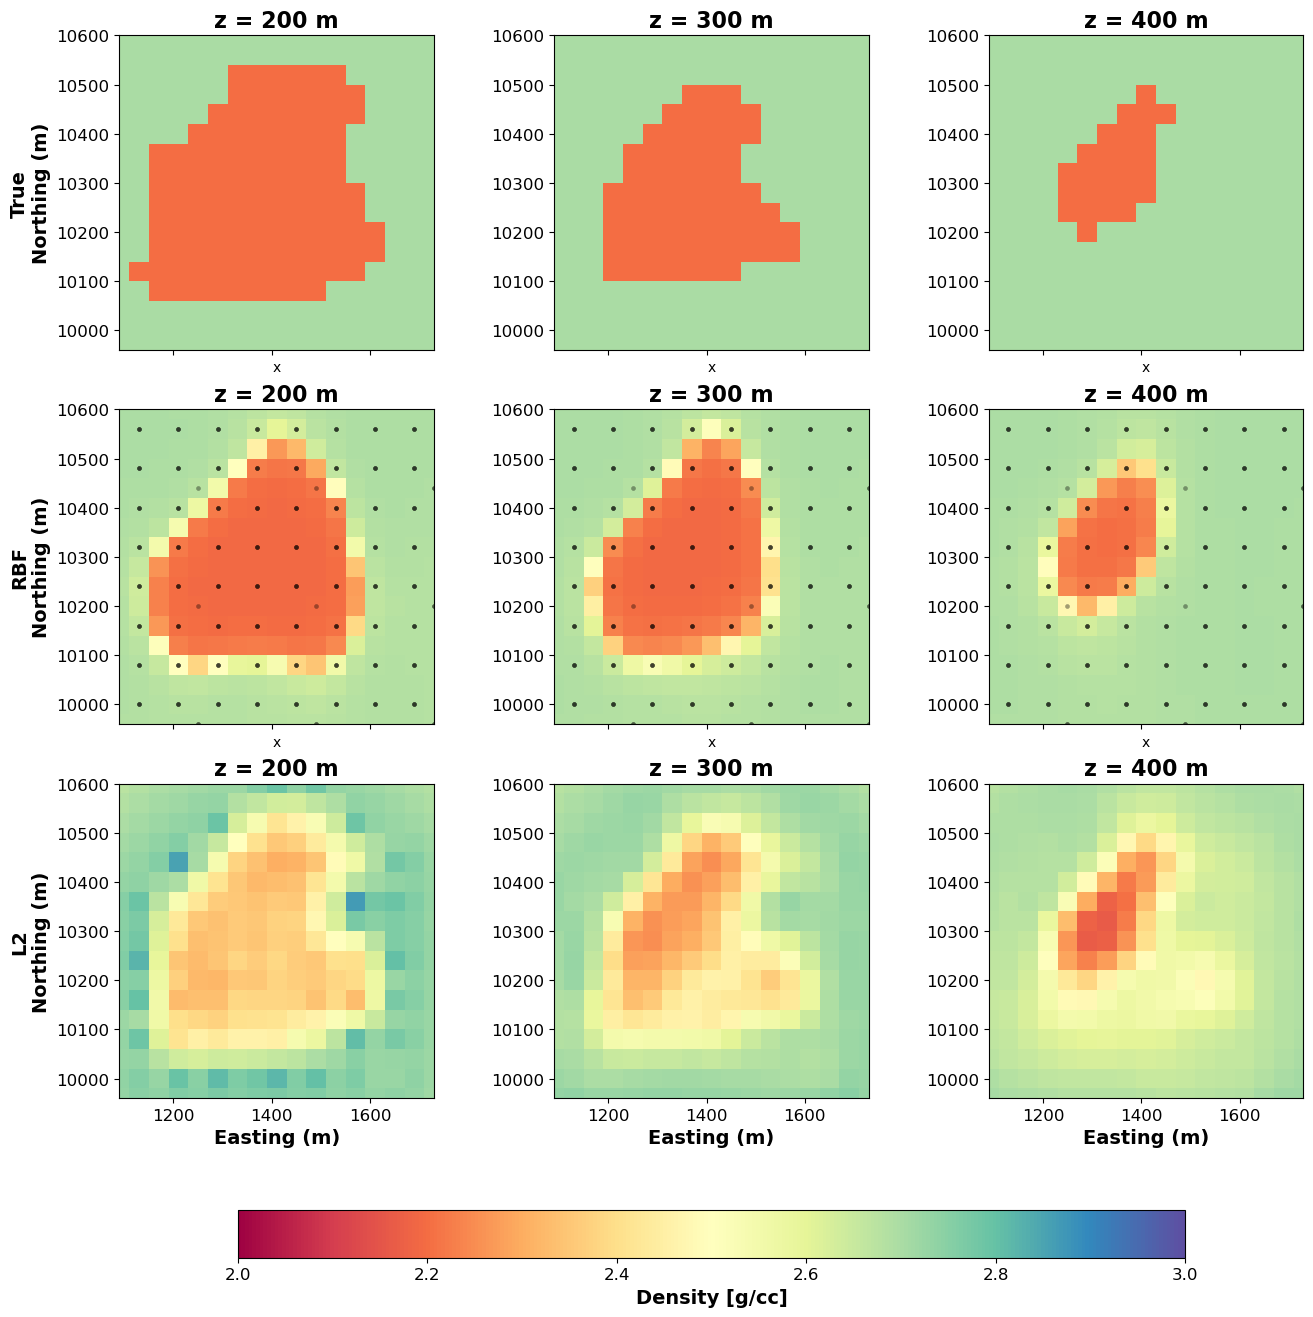

In [76]:
# ============================================================
# Plan-view X-Y slices at different elevations (True, RBF, L2)
# ============================================================
z_elevations = [200, 300, 400]
z_inds = [np.argmin(np.abs(mesh.cell_centers_z - z)) for z in z_elevations]

fig, axes = plt.subplots(3, len(z_inds), figsize=(4.5*len(z_inds), 13), constrained_layout=True)
clim = (2.0, 3.0)

cave_xlim = None
cave_ylim = None
if "cave_ind" in globals() and cave_ind.size > 0:
    cave_xy = rbf_centres[cave_ind][:, :2]
    pad = 200.0
    cave_xlim = (cave_xy[:, 0].min() - pad, cave_xy[:, 0].max() + pad)
    cave_ylim = (cave_xy[:, 1].min() - pad, cave_xy[:, 1].max() + pad)

for j, (zi, zval) in enumerate(zip(z_inds, z_elevations)):
    # True
    ax = axes[0, j]
    mesh.plot_slice(true_model, normal="Z", ax=ax, ind=zi, grid=False,
                    clim=clim, pcolor_opts={"cmap": "Spectral"})
    ax.set_title(f"z = {zval} m", fontsize=16, fontweight="bold")
    ax.set_aspect("equal")
    if cave_xlim is not None:
        ax.set_xlim(cave_xlim)
        ax.set_ylim(cave_ylim)
    if j == 0:
        ax.set_ylabel("True\nNorthing (m)", fontsize=14, fontweight="bold")
    else:
        ax.set_ylabel("")
    ax.tick_params(labelsize=12)
    ax.tick_params(axis="x", labelbottom=False, bottom=True)

    # RBF recovered
    ax = axes[1, j]
    mesh.plot_slice(recovered_model, normal="Z", ax=ax, ind=zi, grid=False,
                    clim=clim, pcolor_opts={"cmap": "Spectral"})
    ax.scatter(rbf_centres[:, 0], rbf_centres[:, 1], c="k", s=10, alpha=0.2,
               edgecolors="k", linewidths=0.1, zorder=8)
    ax.set_aspect("equal")
    if cave_xlim is not None:
        ax.set_xlim(cave_xlim)
        ax.set_ylim(cave_ylim)
    if j == 0:
        ax.set_ylabel("RBF\nNorthing (m)", fontsize=14, fontweight="bold")
    else:
        ax.set_ylabel("")
    ax.tick_params(labelsize=12)
    ax.tick_params(axis="x", labelbottom=False, bottom=True)
    ax.set_title(f"z = {zval} m", fontsize=16, fontweight="bold")

    # L2 recovered
    ax = axes[2, j]
    mesh.plot_slice(recovered_model_l2, normal="Z", ax=ax, ind=zi, grid=False,
                    clim=clim, pcolor_opts={"cmap": "Spectral"})
    ax.set_aspect("equal")
    if cave_xlim is not None:
        ax.set_xlim(cave_xlim)
        ax.set_ylim(cave_ylim)
    if j == 0:
        ax.set_ylabel("L2\nNorthing (m)", fontsize=14, fontweight="bold")
    else:
        ax.set_ylabel("")
    ax.set_xlabel("Easting (m)", fontsize=14, fontweight="bold")
    ax.tick_params(labelsize=12)
    ax.set_title(f"z = {zval} m", fontsize=16, fontweight="bold")

cbar = fig.colorbar(axes[0, -1].collections[0], ax=axes, orientation="horizontal",
                    shrink=0.75, pad=0.05)
cbar.set_label("Density [g/cc]", size=14, fontweight="bold")
cbar.ax.tick_params(labelsize=12)

plt.show()